# 📈 Dự Báo Giá Đóng Cửa — 4 Mã VN30 (VNM · FPT · HPG · VIC)
## Bi-LSTM Multi-step Forecasting: 60 ngày → 14 ngày

**Pipeline (chạy cho từng mã):**
1. Load + sort + split (80/20)
2. MinMaxScaler — fit RIÊNG cho mỗi mã
3. Sliding window (60 → 14)
4. Bi-LSTM 2 lớp + Dropout(0.4)
5. EarlyStopping + ModelCheckpoint
6. Predict + inverse transform
7. RMSE / MAPE tổng quan + per-day
8. 3 chart: Loss curve · Fan chart · Daily error

**Cuối cùng**: bảng tổng kết so sánh 4 mã.

# STAGE 0 — IMPORT THƯ VIỆN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")

2026-05-13 17:02:51.767511: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778691772.052753      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778691772.129218      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778691772.745485      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778691772.745528      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778691772.745532      57 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
NumPy      : 2.0.2
Pandas     : 2.3.3


In [2]:
# Liệt kê file trong /kaggle/input để verify đường dẫn dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/phvngtngtm/vn30-4tickers-datadav/FPT.csv
/kaggle/input/datasets/phvngtngtm/vn30-4tickers-datadav/VNM.csv
/kaggle/input/datasets/phvngtngtm/vn30-4tickers-datadav/HPG.csv
/kaggle/input/datasets/phvngtngtm/vn30-4tickers-datadav/VIC.csv


# CONFIG — Tham số toàn cục

> ⚠️ Sửa `DATASET_DIR` cho đúng với slug Kaggle dataset của bạn sau khi upload thư mục `DataDAV/`.

In [7]:
# ====== ĐƯỜNG DẪN DATASET ======
# Sau khi upload 4 file CSV (VNM/FPT/HPG/VIC) lên Kaggle, sửa dòng dưới cho đúng slug:
DATASET_DIR = "/kaggle/input/datasets/phvngtngtm/vn30-4tickers-datadav/"   # <-- ĐỔI tại đây nếu cần

TICKERS = {
    "VNM": f"{DATASET_DIR}/VNM.csv",
    "FPT": f"{DATASET_DIR}/FPT.csv",
    "HPG": f"{DATASET_DIR}/HPG.csv",
    "VIC": f"{DATASET_DIR}/VIC.csv",
}

# ====== FEATURES & TARGET ======
FEATURES   = ["open", "high", "low", "close", "volume"]
TARGET_COL = "close"
TARGET_IDX = FEATURES.index(TARGET_COL)

# ====== HYPERPARAMS ======
TIME_STEPS       = 60
FORECAST_HORIZON = 14
TRAIN_RATIO      = 0.80
EPOCHS           = 150
BATCH_SIZE       = 16
PATIENCE         = 20

# ====== OUTPUT DIR ======
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"✅ Config loaded — {len(TICKERS)} tickers : {list(TICKERS.keys())}")
print(f"   Features        : {FEATURES}")
print(f"   Time steps      : {TIME_STEPS}")
print(f"   Forecast horizon: {FORECAST_HORIZON} days")
print(f"   Train ratio     : {TRAIN_RATIO*100:.0f}%")

✅ Config loaded — 4 tickers : ['VNM', 'FPT', 'HPG', 'VIC']
   Features        : ['open', 'high', 'low', 'close', 'volume']
   Time steps      : 60
   Forecast horizon: 14 days
   Train ratio     : 80%


# HELPER FUNCTIONS
Các hàm dùng chung — sliding window, inverse transform, build model, metrics.

In [8]:
def create_sequences(data, time_steps=TIME_STEPS, horizon=FORECAST_HORIZON, target_idx=TARGET_IDX):
    """Tạo (X, y) từ mảng đã scaled.
    X : (Samples, time_steps, n_features)
    y : (Samples, horizon)  — chỉ cột target
    """
    X, y = [], []
    total = len(data)
    for i in range(total - time_steps - horizon + 1):
        X.append(data[i : i + time_steps])
        y.append(data[i + time_steps : i + time_steps + horizon, target_idx])
    return np.array(X), np.array(y)


def inverse_close(scaled_values, scaler, mean_scaled, target_idx=TARGET_IDX):
    """Đảo MinMaxScaler về VNĐ gốc bằng dummy array."""
    original_shape = scaled_values.shape
    flat  = scaled_values.reshape(-1)
    dummy = np.tile(mean_scaled, (len(flat), 1))
    dummy[:, target_idx] = flat
    inversed = scaler.inverse_transform(dummy)[:, target_idx]
    return inversed.reshape(original_shape)


def build_bilstm(input_shape, output_steps):
    """Bi-LSTM 2 lớp + Dropout(0.4) + Dense(32) + Dense(horizon)."""
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        Dropout(0.4),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.4),
        Dense(32, activation="relu"),
        Dense(output_steps),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))


def mape(actual, predicted):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100


print("✅ Helpers ready")

✅ Helpers ready


# PIPELINE — Hàm `run_pipeline(ticker, csv_path)`
Train + evaluate + vẽ chart cho 1 mã. Mỗi ticker có scaler, model, file output riêng → không lẫn lộn.

In [16]:
def run_pipeline(ticker: str, csv_path: str) -> dict:
    print(f"\n{'='*64}")
    print(f"  🚀 TRAINING — {ticker}")
    print(f"{'='*64}")

    # Reset seed để 4 mã đều reproducible
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    out_dir = f"{RESULTS_DIR}/{ticker}"
    os.makedirs(out_dir, exist_ok=True)

    model_path     = f"{out_dir}/best_bilstm_{ticker.lower()}.keras"
    chart_loss     = f"{out_dir}/{ticker}_loss_curve.png"
    chart_forecast = f"{out_dir}/{ticker}_forecast_chart.png"
    chart_daily    = f"{out_dir}/{ticker}_daily_error.png"

    # ============ 1A. LOAD ============
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip().str.lower()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    print(f"  Dataset : {df.shape}  ({df['date'].min().date()} → {df['date'].max().date()})")

    # ============ 1B. SPLIT ============
    split_idx = int(len(df) * TRAIN_RATIO)
    df_train  = df.iloc[:split_idx].copy()
    df_test   = df.iloc[split_idx:].copy()
    print(f"  Train   : {len(df_train)} rows | Test : {len(df_test)} rows")

    # ============ 1C. SCALE (fit on train only) ============
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(df_train[FEATURES].values)
    test_scaled  = scaler.transform(df_test[FEATURES].values)
    train_mean_scaled = train_scaled.mean(axis=0)

    # ============ 2. SLIDING WINDOW ============
    X_train, y_train = create_sequences(train_scaled)
    test_scaled_extended = np.vstack((train_scaled[-TIME_STEPS:], test_scaled))
    X_test,  y_test  = create_sequences(test_scaled_extended)
    print(f"  X_train : {X_train.shape} | X_test : {X_test.shape}")

    # ============ 3. BUILD MODEL ============
    model = build_bilstm((TIME_STEPS, len(FEATURES)), FORECAST_HORIZON)

    # ============ 4. TRAIN ============
    early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE,
                               restore_best_weights=True, verbose=0)
    checkpoint = ModelCheckpoint(filepath=model_path, monitor="val_loss",
                                 save_best_only=True, verbose=0)
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, checkpoint],
        verbose=0,
    )
    best_ep = int(np.argmin(history.history["val_loss"])) + 1
    total_ep = len(history.history["loss"])
    print(f"  ✅ Trained — best epoch {best_ep}/{total_ep}")

    # ============ 5. PREDICT + INVERSE ============
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = inverse_close(y_pred_scaled, scaler, train_mean_scaled)
    y_true = inverse_close(y_test,        scaler, train_mean_scaled)

    # ============ 6. EVALUATE ============
    overall_rmse = rmse(y_true.flatten(), y_pred.flatten())
    overall_mape = mape(y_true.flatten(), y_pred.flatten())
    daily_rmse = [rmse(y_true[:, d], y_pred[:, d]) for d in range(FORECAST_HORIZON)]
    daily_mape = [mape(y_true[:, d], y_pred[:, d]) for d in range(FORECAST_HORIZON)]
    print(f"  RMSE = {overall_rmse:,.2f} VNĐ | MAPE = {overall_mape:.2f}%")

    # ============ 7A. LOSS CURVE ============
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history["loss"],     label="Train Loss",      color="#2196F3", linewidth=2)
    ax.plot(history.history["val_loss"], label="Validation Loss", color="#FF5722",
            linewidth=2, linestyle="--")
    ax.axvline(best_ep - 1, color="gray", linestyle=":", linewidth=1.5,
               label=f"Best epoch ({best_ep})")
    ax.set_title(f"{ticker} — Training vs Validation Loss",
                 fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(framealpha=0.9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(chart_loss, dpi=150, bbox_inches="tight")
    plt.show()

    # ============ 7B. FAN CHART ============
    actual_day1 = y_true[:, 0]
    pred_day1   = y_pred[:, 0]
    n_samples   = len(actual_day1)
    x_axis      = np.arange(n_samples)
    branch_indices = [int(n_samples * 0.10), int(n_samples * 0.50), int(n_samples * 0.85)]
    branch_colors  = ["#9C27B0", "#FF9800", "#009688"]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(x_axis, actual_day1, color="#1565C0", linewidth=2.0,
            label="Actual Close Price", zorder=3)
    ax.plot(x_axis, pred_day1, color="#E53935", linewidth=1.8, linestyle="--",
            label="Predicted Day 1", zorder=3)
    for idx, color in zip(branch_indices, branch_colors):
        bx = np.arange(idx, idx + FORECAST_HORIZON)
        by = y_pred[idx]
        ax.plot(bx, by, color=color, linewidth=2.2, marker="o",
                markersize=4, zorder=4, alpha=0.85)
        ax.fill_between(bx, by * 0.98, by * 1.02, color=color, alpha=0.15)
        ax.scatter(idx, actual_day1[idx], color=color, s=80, zorder=5,
                   edgecolors="white", linewidths=1.5)
        ax.annotate(f"Forecast\n@sample {idx}",
                    xy=(idx, actual_day1[idx]),
                    xytext=(idx + 1, actual_day1[idx] + actual_day1[idx]*0.015),
                    fontsize=7.5, color=color, fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.2))
    ax.set_title(f"{ticker} Close Price — Actual vs Predicted (Bi-LSTM, {FORECAST_HORIZON}-Day Forecast)",
                 fontsize=14, fontweight="bold", pad=14)
    ax.set_xlabel("Sample Index (Test Set)", fontsize=11)
    ax.set_ylabel("Giá Đóng Cửa (VNĐ)", fontsize=11)
    ax.legend(loc="upper left", framealpha=0.9, fontsize=10)
    ax.grid(True, alpha=0.25)
    textstr = f"RMSE: {overall_rmse:,.0f} VNĐ\nMAPE: {overall_mape:.2f}%"
    ax.text(0.98, 0.05, textstr, transform=ax.transAxes, fontsize=9.5,
            verticalalignment="bottom", horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.85))
    plt.tight_layout()
    plt.savefig(chart_forecast, dpi=150, bbox_inches="tight")
    plt.show()

    # ============ 7C. DAILY ERROR ============
    days = [f"D{i+1}" for i in range(FORECAST_HORIZON)]
    x = np.arange(FORECAST_HORIZON)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    bars1 = ax1.bar(x, daily_rmse, width=0.6, color="#42A5F5", edgecolor="white")
    ax1.set_title(f"{ticker} — RMSE theo từng ngày", fontweight="bold", pad=15)
    ax1.set_xticks(x); ax1.set_xticklabels(days); ax1.set_ylabel("RMSE (VNĐ)")
    ax1.grid(axis="y", alpha=0.3)
    ax1.set_ylim(0, max(daily_rmse) * 1.15)
    for b in bars1:
        h = b.get_height()
        ax1.text(b.get_x() + b.get_width()/2, h + max(daily_rmse)*0.02,
                 f"{h:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    bars2 = ax2.bar(x, daily_mape, width=0.6, color="#EF5350", edgecolor="white")
    ax2.set_title(f"{ticker} — MAPE (%) theo từng ngày", fontweight="bold", pad=15)
    ax2.set_xticks(x); ax2.set_xticklabels(days); ax2.set_ylabel("MAPE (%)")
    ax2.grid(axis="y", alpha=0.3)
    ax2.set_ylim(0, max(daily_mape) * 1.15)
    for b in bars2:
        h = b.get_height()
        ax2.text(b.get_x() + b.get_width()/2, h + max(daily_mape)*0.02,
                 f"{h:.2f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.suptitle(f"{ticker} — Sai số dự báo theo horizon",
                 fontsize=11, style="italic", color="gray", y=1.02)
    plt.tight_layout()
    plt.savefig(chart_daily, dpi=150, bbox_inches="tight")
    plt.show()

    return {
        "ticker":     ticker,
        "rmse":       overall_rmse,
        "mape":       overall_mape,
        "best_epoch": best_ep,
        "total_epoch": total_ep,
        "daily_rmse": daily_rmse,
        "daily_mape": daily_mape,
        "model_path": model_path,
    }

# RUN — Train cho cả 4 mã


  🚀 TRAINING — VNM
  Dataset : (1286, 25)  (2020-11-09 → 2025-12-31)
  Train   : 1028 rows | Test : 258 rows
  X_train : (955, 60, 5) | X_test : (245, 60, 5)


2026-05-13 17:13:21.867029: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  ✅ Trained — best epoch 5/25
  RMSE = 2.49 VNĐ | MAPE = 3.56%


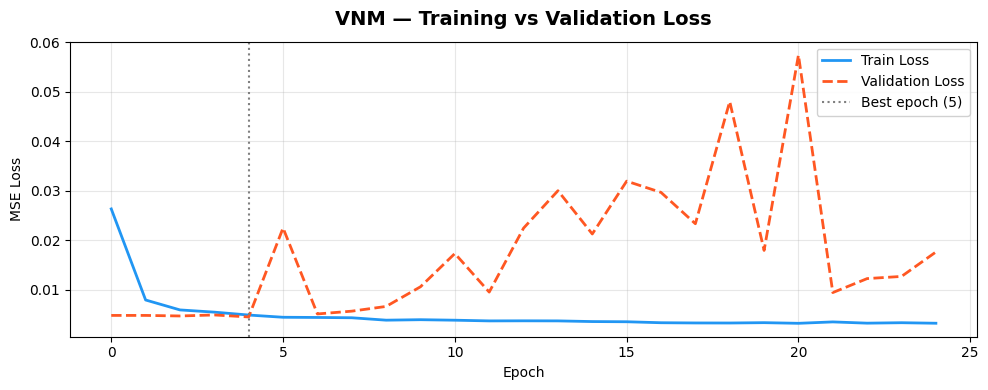

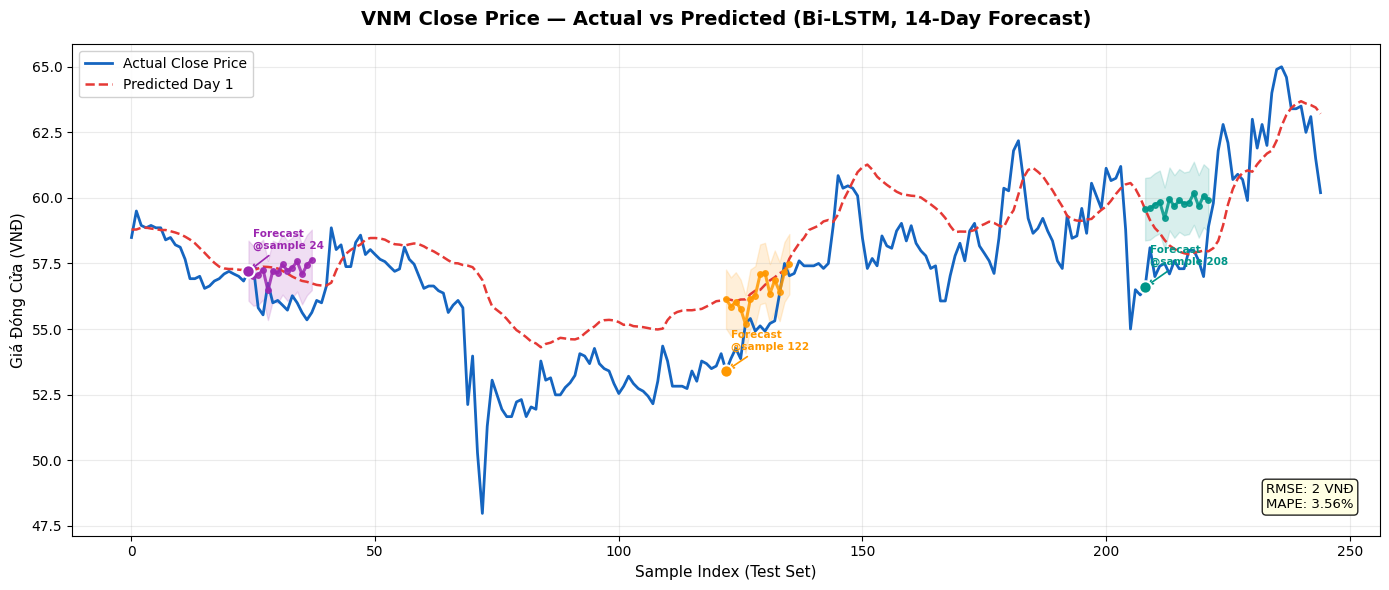

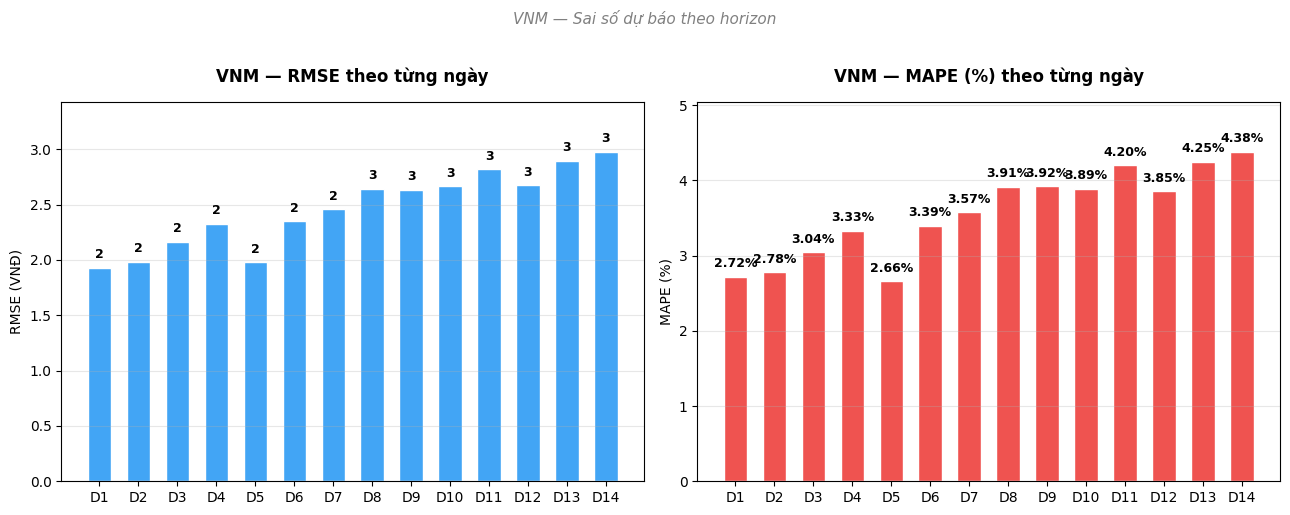


  🚀 TRAINING — FPT
  Dataset : (1286, 25)  (2020-11-09 → 2025-12-31)
  Train   : 1028 rows | Test : 258 rows
  X_train : (955, 60, 5) | X_test : (245, 60, 5)
  ✅ Trained — best epoch 15/35
  RMSE = 9.06 VNĐ | MAPE = 6.61%


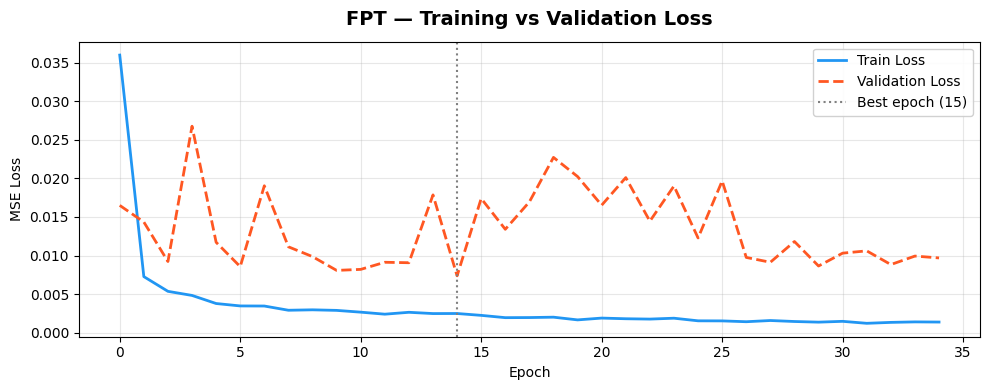

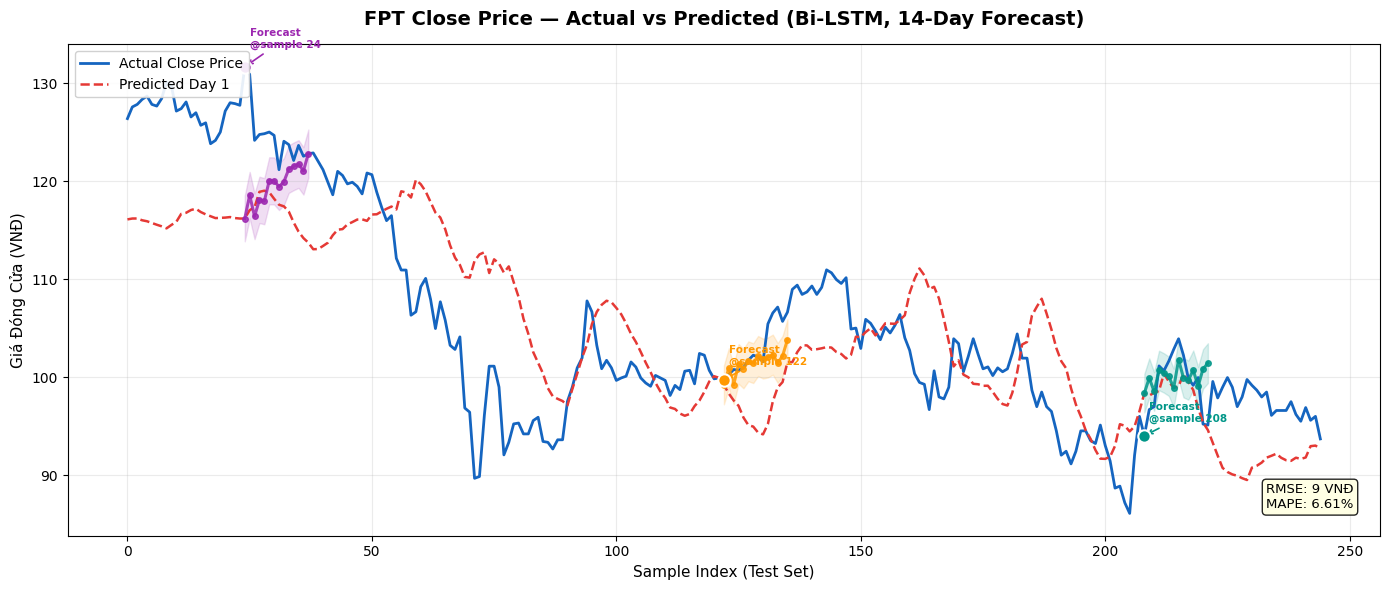

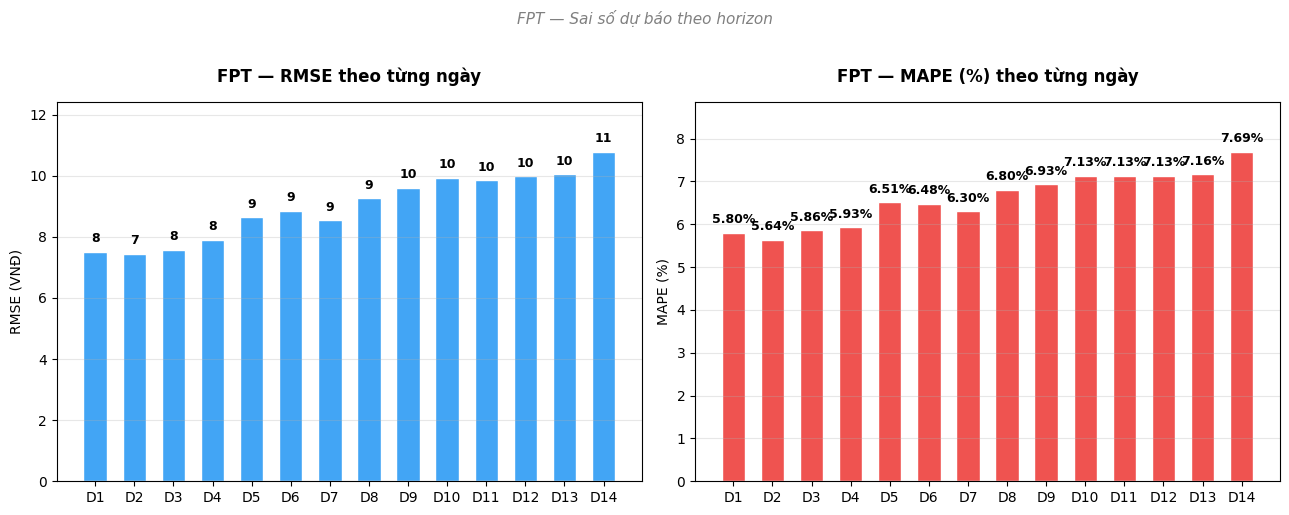


  🚀 TRAINING — HPG
  Dataset : (1286, 25)  (2020-11-09 → 2025-12-31)
  Train   : 1028 rows | Test : 258 rows
  X_train : (955, 60, 5) | X_test : (245, 60, 5)
  ✅ Trained — best epoch 7/27
  RMSE = 1.28 VNĐ | MAPE = 4.12%


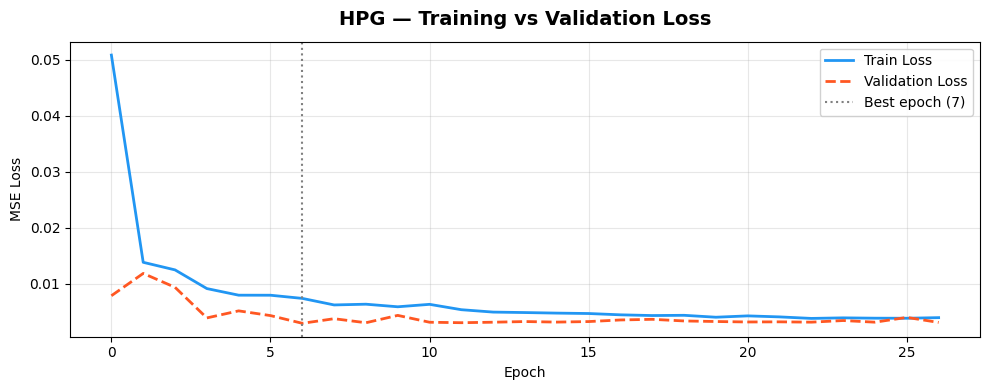

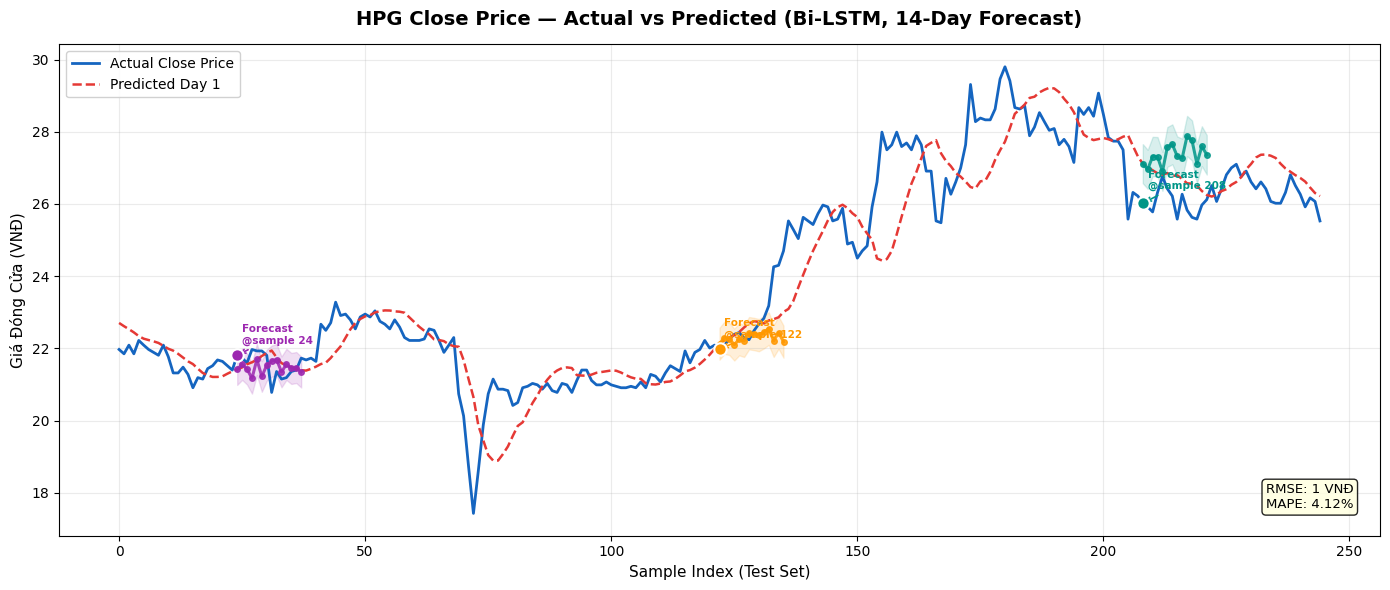

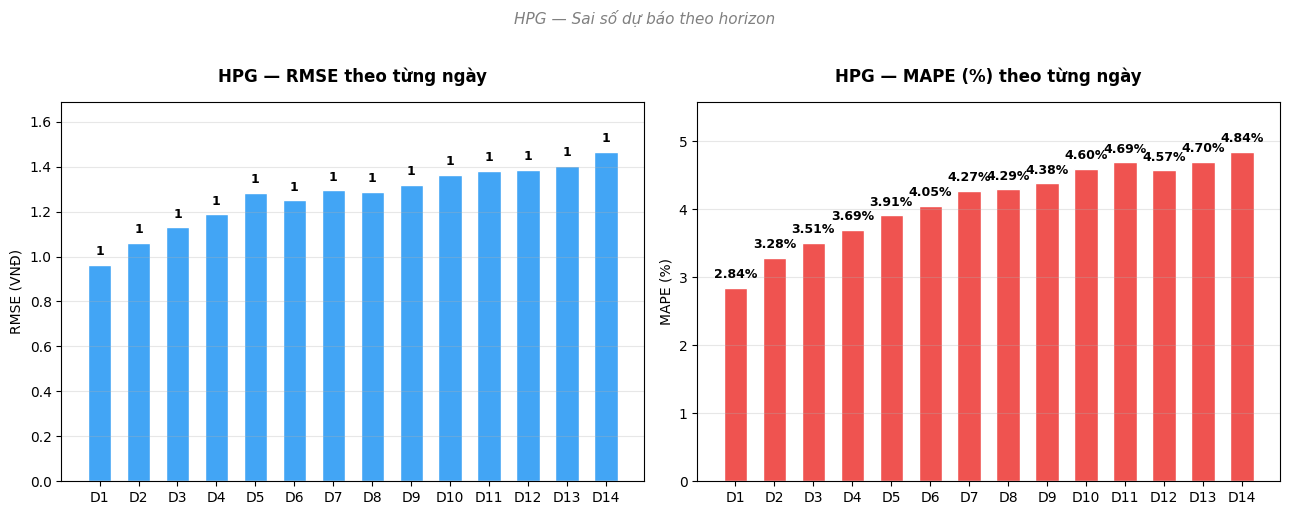


  🚀 TRAINING — VIC
  Dataset : (1286, 25)  (2020-11-09 → 2025-12-31)
  Train   : 1028 rows | Test : 258 rows
  X_train : (955, 60, 5) | X_test : (245, 60, 5)
  ✅ Trained — best epoch 11/31
  RMSE = 16.10 VNĐ | MAPE = 15.04%


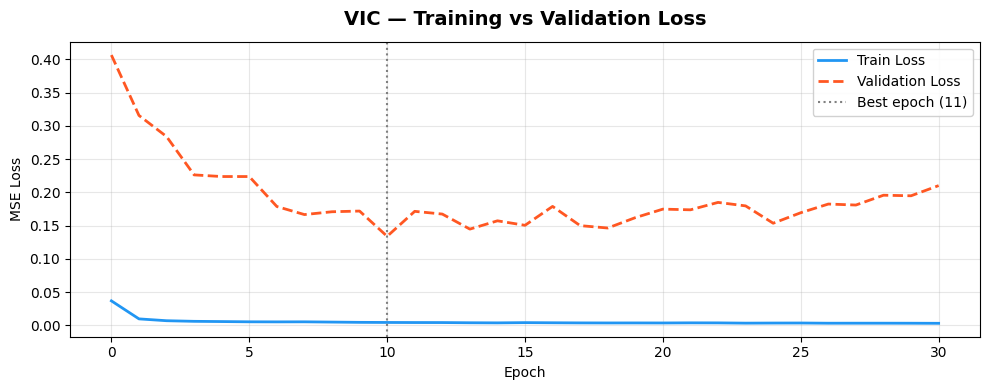

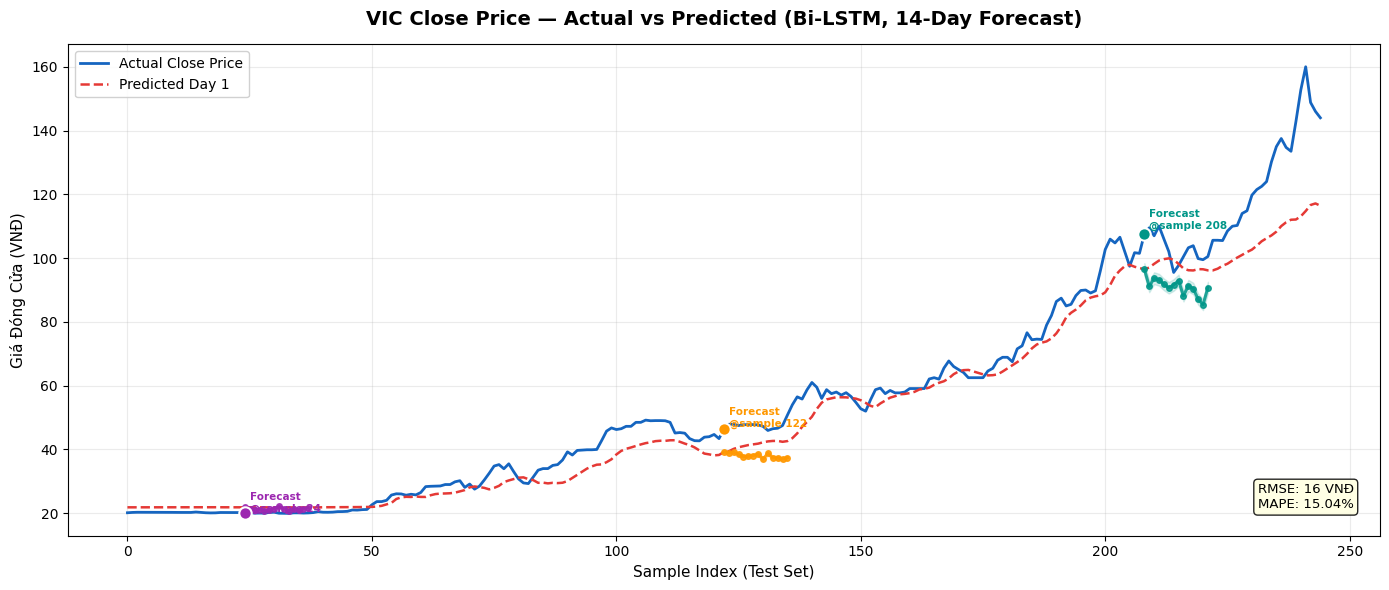

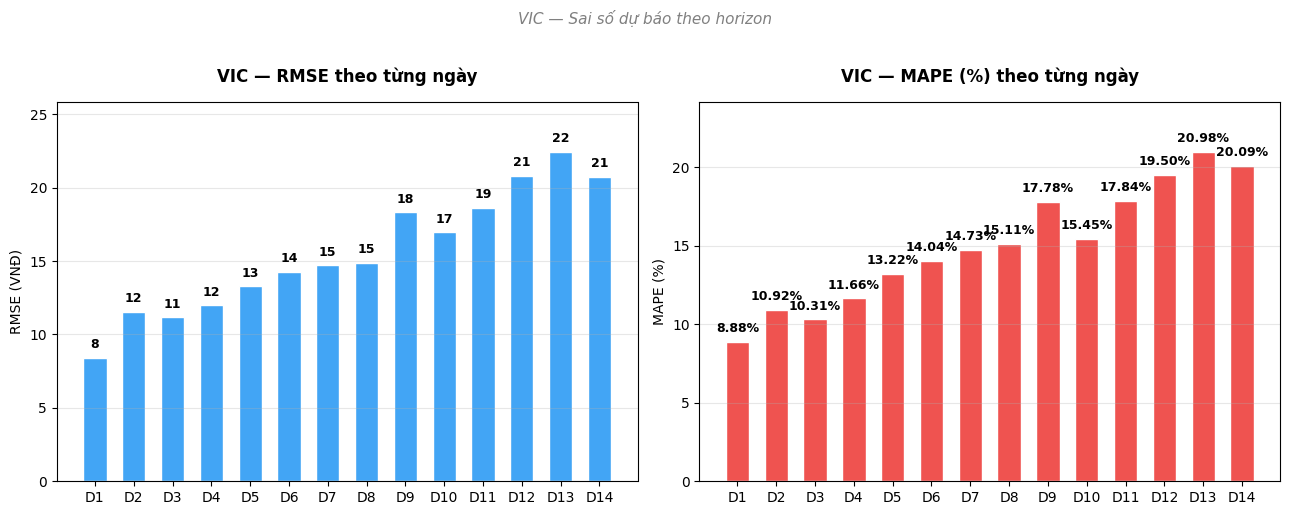

In [10]:
results = []
for ticker, path in TICKERS.items():
    res = run_pipeline(ticker, path)
    results.append(res)

# TỔNG KẾT — So sánh 4 mã

In [19]:
summary_df = pd.DataFrame([{
    "Ticker":      r["ticker"],
    "Best Epoch":  f"{r['best_epoch']}/{r['total_epoch']}",
    "RMSE (VNĐ)":  round(r["rmse"], 2),
    "MAPE (%)":    round(r["mape"], 2),
    "Model File":  r["model_path"],
} for r in results])

print("=" * 70)
print("  TỔNG KẾT — Bi-LSTM 14-day forecast trên 4 mã VN30")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)

summary_df.to_csv(f"{RESULTS_DIR}/summary.csv", index=False)
print(f"\n Đã lưu tổng kết: {RESULTS_DIR}/summary.csv")

  TỔNG KẾT — Bi-LSTM 14-day forecast trên 4 mã VN30
Ticker Best Epoch  RMSE (VNĐ)  MAPE (%)                        Model File
   VNM       5/25        2.49      3.56 results/VNM/best_bilstm_vnm.keras
   FPT      15/35        9.06      6.61 results/FPT/best_bilstm_fpt.keras
   HPG       7/27        1.28      4.12 results/HPG/best_bilstm_hpg.keras
   VIC      11/31       16.10     15.04 results/VIC/best_bilstm_vic.keras

 Đã lưu tổng kết: results/summary.csv


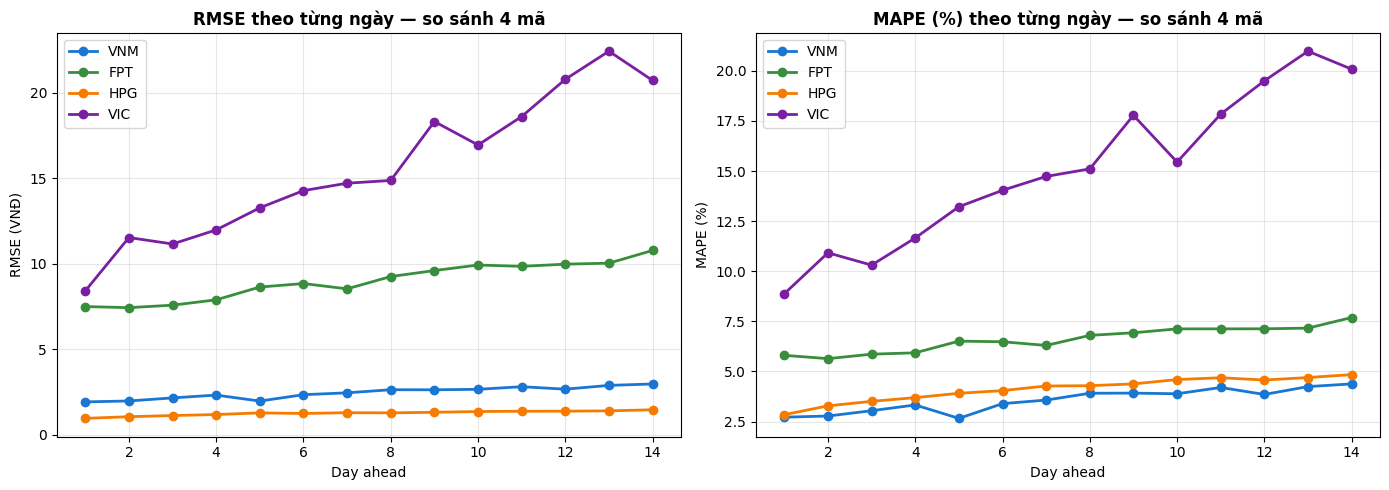

 Đã lưu: results/comparison_4tickers.png


In [21]:
# Biểu đồ so sánh MAPE 4 mã theo từng ngày
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = {"VNM": "#1976D2", "FPT": "#388E3C", "HPG": "#F57C00", "VIC": "#7B1FA2"}
days_x = np.arange(1, FORECAST_HORIZON + 1)

for r in results:
    c = colors.get(r["ticker"], "#666")
    ax1.plot(days_x, r["daily_rmse"], marker="o", linewidth=2,
             label=r["ticker"], color=c)
    ax2.plot(days_x, r["daily_mape"], marker="o", linewidth=2,
             label=r["ticker"], color=c)

ax1.set_title("RMSE theo từng ngày — so sánh 4 mã", fontweight="bold")
ax1.set_xlabel("Day ahead"); ax1.set_ylabel("RMSE (VNĐ)")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_title("MAPE (%) theo từng ngày — so sánh 4 mã", fontweight="bold")
ax2.set_xlabel("Day ahead"); ax2.set_ylabel("MAPE (%)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/comparison_4tickers.png", dpi=150, bbox_inches="tight")
plt.show()
print(f" Đã lưu: {RESULTS_DIR}/comparison_4tickers.png")

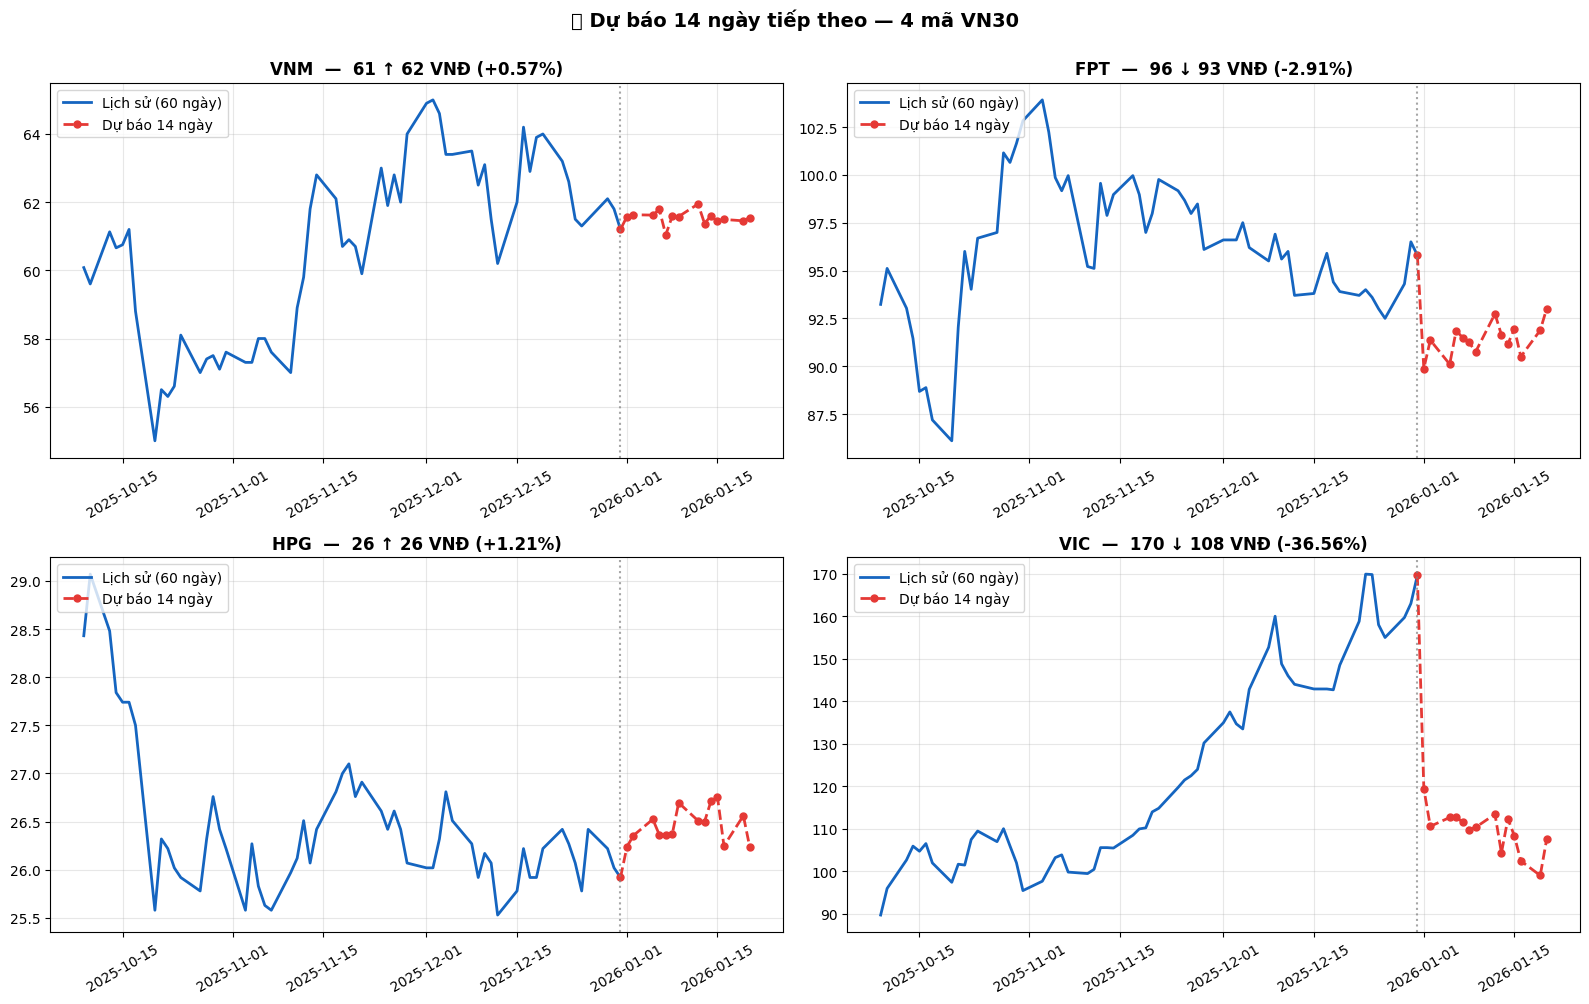


  🔮 DỰ BÁO 14 NGÀY TIẾP THEO
Ticker Giá hiện tại (VNĐ) Sau 14 ngày (VNĐ) Thay đổi Min trong 14 ngày Max trong 14 ngày
   VNM                 61                62   +0.57%                61                62
   FPT                 96                93   -2.91%                90                93
   HPG                 26                26   +1.21%                26                27
   VIC                170               108  -36.56%                99               119


In [22]:
# ============== TEST DỰ ĐOÁN 14 NGÀY TIẾP THEO ==============

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
forecasts = {}

for i, (ticker, csv_path) in enumerate(TICKERS.items()):
    # Reload data + refit scaler trên 80% train (giống lúc training)
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip().str.lower()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    split_idx = int(len(df) * TRAIN_RATIO)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(df.iloc[:split_idx][FEATURES].values)
    train_mean_scaled = train_scaled.mean(axis=0)
    full_scaled = scaler.transform(df[FEATURES].values)

    # Lấy 60 ngày cuối làm input → predict 14 ngày tới
    X_future = full_scaled[-TIME_STEPS:].reshape(1, TIME_STEPS, len(FEATURES))
    model = tf.keras.models.load_model(f"{RESULTS_DIR}/{ticker}/best_bilstm_{ticker.lower()}.keras")
    y_pred = inverse_close(model.predict(X_future, verbose=0)[0], scaler, train_mean_scaled)

    last_date    = df["date"].iloc[-1]
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_HORIZON)
    current      = df["close"].iloc[-1]
    forecasts[ticker] = {
        "current":      current,
        "predicted":    y_pred,
        "future_dates": future_dates,
        "change_pct":   (y_pred[-1] - current) / current * 100,
    }

    # Plot lịch sử 60 ngày + forecast 14 ngày
    ax = axes[i]
    hist_dates = df["date"].iloc[-60:]
    hist_close = df["close"].iloc[-60:]
    ax.plot(hist_dates, hist_close, color="#1565C0", linewidth=2, label="Lịch sử (60 ngày)")
    ax.plot([hist_dates.iloc[-1]] + list(future_dates),
            [hist_close.iloc[-1]] + list(y_pred),
            color="#E53935", linewidth=2, linestyle="--", marker="o",
            markersize=5, label="Dự báo 14 ngày")
    ax.axvline(hist_dates.iloc[-1], color="gray", linestyle=":", alpha=0.7)
    arrow = "↑" if y_pred[-1] > current else "↓"
    ax.set_title(f"{ticker}  —  {current:,.0f} {arrow} {y_pred[-1]:,.0f} VNĐ "
                 f"({(y_pred[-1]-current)/current*100:+.2f}%)",
                 fontweight="bold", fontsize=12)
    ax.legend(loc="upper left"); ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Dự báo 14 ngày tiếp theo — 4 mã VN30",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/future_forecast_4tickers.png", dpi=150, bbox_inches="tight")
plt.show()

# Bảng tổng hợp
print("\n" + "=" * 70)
print("  🔮 DỰ BÁO 14 NGÀY TIẾP THEO")
print("=" * 70)
fc_df = pd.DataFrame([{
    "Ticker":             t,
    "Giá hiện tại (VNĐ)": f"{f['current']:,.0f}",
    "Sau 14 ngày (VNĐ)":  f"{f['predicted'][-1]:,.0f}",
    "Thay đổi":           f"{f['change_pct']:+.2f}%",
    "Min trong 14 ngày":  f"{f['predicted'].min():,.0f}",
    "Max trong 14 ngày":  f"{f['predicted'].max():,.0f}",
} for t, f in forecasts.items()])
print(fc_df.to_string(index=False))


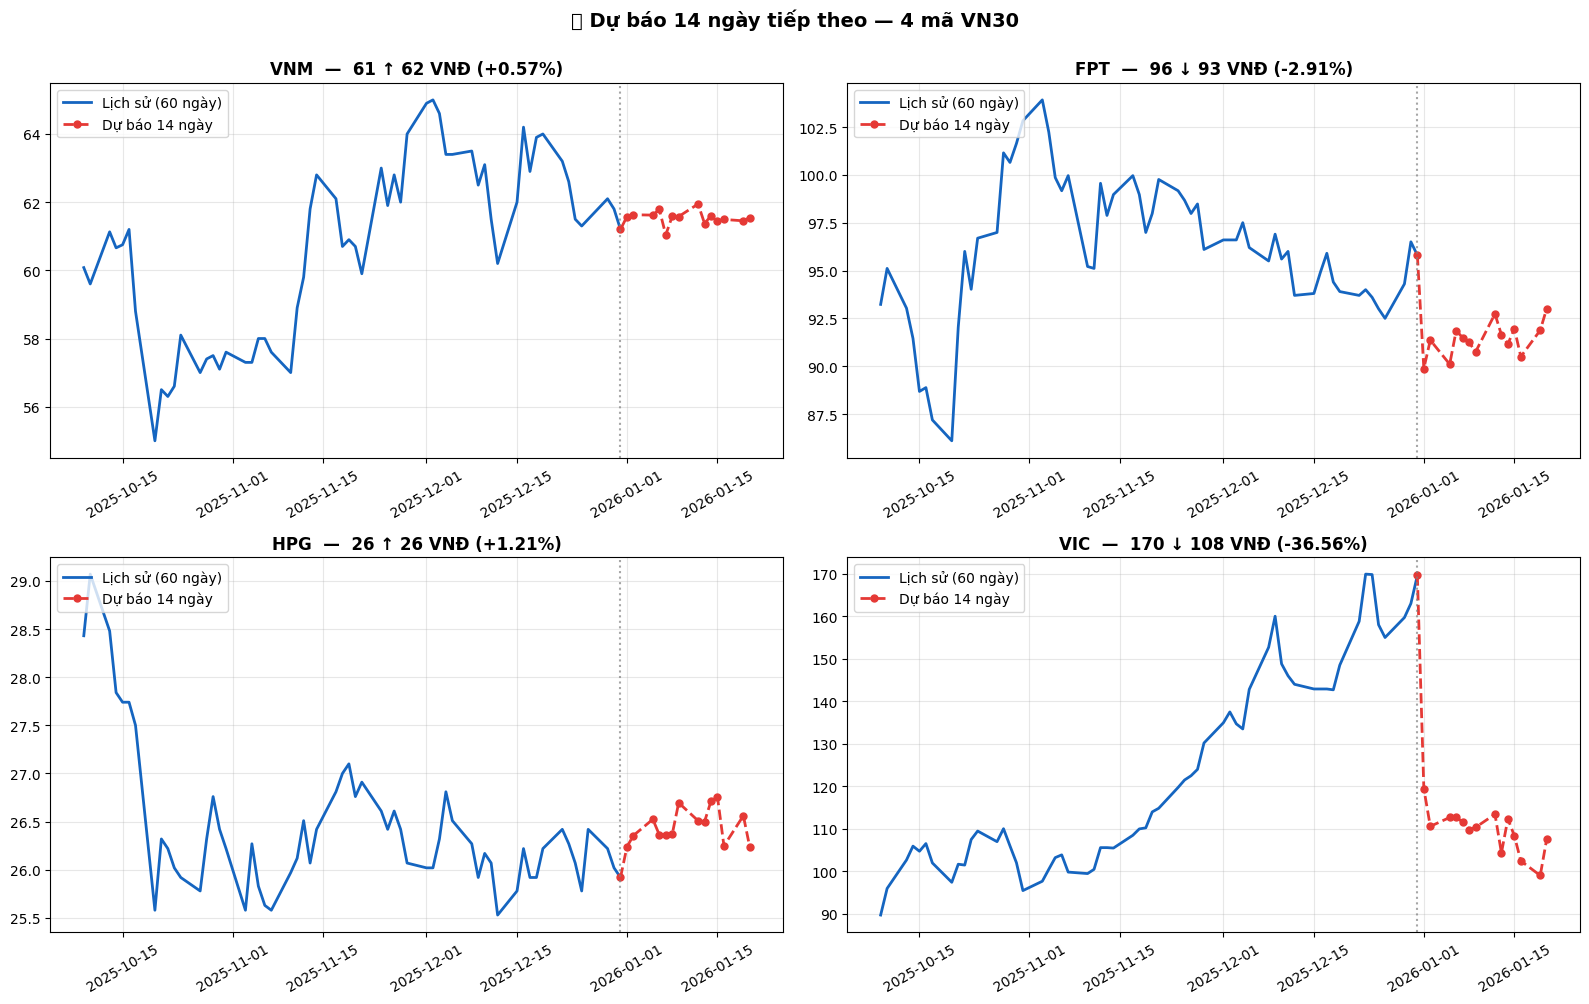

  DỰ BÁO 14 NGÀY TIẾP THEO
Ticker Giá hiện tại (VNĐ) Sau 14 ngày (VNĐ) Thay đổi Min trong 14 ngày Max trong 14 ngày
   VNM                 61                62   +0.57%                61                62
   FPT                 96                93   -2.91%                90                93
   HPG                 26                26   +1.21%                26                27
   VIC                170               108  -36.56%                99               119
 Đã lưu: results/future_forecast.csv


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
forecasts = {}

for i, (ticker, csv_path) in enumerate(TICKERS.items()):
    # Reload data + refit scaler trên 80% train (giống lúc training)
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip().str.lower()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    split_idx = int(len(df) * TRAIN_RATIO)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(df.iloc[:split_idx][FEATURES].values)
    train_mean_scaled = train_scaled.mean(axis=0)
    full_scaled = scaler.transform(df[FEATURES].values)

    # Lấy 60 ngày cuối làm input → predict 14 ngày tới
    X_future = full_scaled[-TIME_STEPS:].reshape(1, TIME_STEPS, len(FEATURES))
    model = tf.keras.models.load_model(
        f"{RESULTS_DIR}/{ticker}/best_bilstm_{ticker.lower()}.keras"
    )
    y_pred = inverse_close(model.predict(X_future, verbose=0)[0],
                           scaler, train_mean_scaled)

    last_date    = df["date"].iloc[-1]
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1),
                                  periods=FORECAST_HORIZON)
    current      = df["close"].iloc[-1]
    forecasts[ticker] = {
        "current":      current,
        "predicted":    y_pred,
        "future_dates": future_dates,
        "change_pct":   (y_pred[-1] - current) / current * 100,
    }

    # Plot lịch sử 60 ngày + forecast 14 ngày
    ax = axes[i]
    hist_dates = df["date"].iloc[-60:]
    hist_close = df["close"].iloc[-60:]
    ax.plot(hist_dates, hist_close, color="#1565C0", linewidth=2,
            label="Lịch sử (60 ngày)")
    ax.plot([hist_dates.iloc[-1]] + list(future_dates),
            [hist_close.iloc[-1]] + list(y_pred),
            color="#E53935", linewidth=2, linestyle="--", marker="o",
            markersize=5, label="Dự báo 14 ngày")
    ax.axvline(hist_dates.iloc[-1], color="gray", linestyle=":", alpha=0.7)
    arrow = "↑" if y_pred[-1] > current else "↓"
    ax.set_title(
        f"{ticker}  —  {current:,.0f} {arrow} {y_pred[-1]:,.0f} VNĐ "
        f"({(y_pred[-1]-current)/current*100:+.2f}%)",
        fontweight="bold", fontsize=12
    )
    ax.legend(loc="upper left"); ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("🔮 Dự báo 14 ngày tiếp theo — 4 mã VN30",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/future_forecast_4tickers.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Bảng tổng hợp
print("  DỰ BÁO 14 NGÀY TIẾP THEO")
print("=" * 70)
fc_df = pd.DataFrame([{
    "Ticker":             t,
    "Giá hiện tại (VNĐ)": f"{f['current']:,.0f}",
    "Sau 14 ngày (VNĐ)":  f"{f['predicted'][-1]:,.0f}",
    "Thay đổi":           f"{f['change_pct']:+.2f}%",
    "Min trong 14 ngày":  f"{f['predicted'].min():,.0f}",
    "Max trong 14 ngày":  f"{f['predicted'].max():,.0f}",
} for t, f in forecasts.items()])
print(fc_df.to_string(index=False))

fc_df.to_csv(f"{RESULTS_DIR}/future_forecast.csv", index=False)
print(f" Đã lưu: {RESULTS_DIR}/future_forecast.csv")

In [32]:
import shutil
from pathlib import Path

ZIP_NAME = "multi_stock_forecast_results"
zip_path = shutil.make_archive(ZIP_NAME, "zip", RESULTS_DIR)
size_mb  = Path(zip_path).stat().st_size / 1024 / 1024

print("=" * 70)
print(f"  ĐÃ ĐÓNG GÓI: {Path(zip_path).name}  ({size_mb:.2f} MB)")
print("=" * 70)

# Liệt kê nội dung
print(f"Nội dung (từ thư mục '{RESULTS_DIR}/'):")
files = sorted(Path(RESULTS_DIR).rglob("*"))
for p in files:
    if p.is_file():
        rel = p.relative_to(RESULTS_DIR)
        kb  = p.stat().st_size / 1024
        print(f"   {str(rel):<50} {kb:>8.1f} KB")

n_files = sum(1 for p in files if p.is_file())
print(f"Tổng: {n_files} files")
print(f"Trên Kaggle: tab 'Output' bên phải → tải '{ZIP_NAME}.zip'")

  ĐÃ ĐÓNG GÓI: multi_stock_forecast_results.zip  (7.55 MB)
Nội dung (từ thư mục 'results/'):
   FPT/FPT_daily_error.png                                73.7 KB
   FPT/FPT_forecast_chart.png                            204.5 KB
   FPT/FPT_loss_curve.png                                 80.1 KB
   FPT/best_bilstm_fpt.keras                            1693.1 KB
   HPG/HPG_daily_error.png                                75.3 KB
   HPG/HPG_forecast_chart.png                            185.8 KB
   HPG/HPG_loss_curve.png                                 56.8 KB
   HPG/best_bilstm_hpg.keras                            1693.1 KB
   VIC/VIC_daily_error.png                                75.8 KB
   VIC/VIC_forecast_chart.png                            139.9 KB
   VIC/VIC_loss_curve.png                                 61.2 KB
   VIC/best_bilstm_vic.keras                            1693.1 KB
   VNM/VNM_daily_error.png                                75.4 KB
   VNM/VNM_forecast_chart.png                    